In [1]:
%load_ext autoreload
%autoreload 2
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm
import cartopy.crs as ccrs
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion

### Request HPC Resources

In [4]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/user/anthony.meza/CM4XAbyssalSWMT/notebooks/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='160GB',
    walltime='8:00:00',
    queue='compute',
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=8)
cluster.wait_for_workers(4)
client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /user/anthony.meza/CM4XAbyssalSWMT/notebooks/logs/dask-worker-%J.err
#SBATCH -o /user/anthony.meza/CM4XAbyssalSWMT/notebooks/logs/dask-worker-%J.out
#SBATCH -p compute
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=150G
#SBATCH -t 8:00:00

/user/anthony.meza/miniforge3/envs/cm4x_chapter2/bin/python -m distributed.cli.dask_worker tcp://10.151.1.61:41593 --name dummy-name --nthreads 36 --memory-limit 149.01GiB --nanny --death-timeout 60



<Client: 'tcp://10.151.1.61:41593' processes=4 threads=144, memory=596.04 GiB>

### Load in data

In [5]:
# Key water mass transformation budget terms
budget_terms = [
    # 'Eulerian_tendency', 'advection', 'diffusion', 
            'boundary_fluxes', #'convergent_mass_transport', 
           # 'mass_tendency', 'mass_source', 'spurious_numerical_mixing', 
           "surface_exchange_flux", "bottom_flux", "frazil_ice", 
            "surface_ocean_flux_advective_negative_rhs"]

other_budget_terms = ["surface_ocean_flux_advective_negative_rhs_heat", 
                     "surface_ocean_flux_advective_negative_rhs_salt", 
                     "surface_exchange_flux_heat", 
                     "surface_exchange_flux_salt", 
                     "frazil_ice_heat", 
                     "bottom_flux_heat",
                     "boundary_fluxes", 
                     # "mass_tendency", 
                     # "diffusion_heat", 
                     # "diffusion_salt",
                     # "spurious_numerical_mixing",
                     # "convergent_mass_transport"
                     ]
budget_terms= sorted(list(set(budget_terms) | set(other_budget_terms)))

In [6]:
decomp_budget_terms = ["surface_exchange_flux_advective_evaporation_salt", 
                    "surface_exchange_flux_advective_rain_and_ice_salt",
                    "surface_exchange_flux_advective_snow_salt",
                    "surface_exchange_flux_advective_rivers_salt", 
                    "surface_exchange_flux_advective_icebergs_salt",
                    "surface_exchange_flux_advective_virtual_precip_restoring_salt",
                    "surface_exchange_flux_advective_sea_ice_salt",
                    "surface_exchange_flux_nonadvective_basal_salt",
                    "surface_exchange_flux_nonadvective_longwave_heat", 
                    "surface_exchange_flux_nonadvective_shortwave_heat",
                    "surface_exchange_flux_nonadvective_sensible_heat",
                    "surface_exchange_flux_nonadvective_latent_heat", 
                    "surface_exchange_flux_advective_mass_transfer_heat"]

In [7]:
def decompose_boundary_fluxes(ds): 
    ds["boundary_fluxes_heat"] = ds["surface_ocean_flux_advective_negative_rhs_heat"] +\
                             ds["surface_exchange_flux_heat"] +\
                             ds["frazil_ice_heat"] + ds["bottom_flux_heat"]

    ds["boundary_fluxes_salt"] = ds["surface_ocean_flux_advective_negative_rhs_salt"] +\
                                     ds["surface_exchange_flux_salt"]

    ds["surface_boundary_fluxes_salt"] = 1 * ds["boundary_fluxes_salt"]
    ds["surface_boundary_fluxes_heat"] = ds["boundary_fluxes_heat"] - ds["bottom_flux_heat"]

In [28]:
import glob
datadir = lambda x="" : "/proj/ecco/CM4X/budget_sigma2_v1.2.0/" + x
datafiles = glob.glob(datadir("CM4Xp125*"))[20:]
datafiles = sorted(datafiles)

wmts = []

for (t, file) in enumerate(datafiles): 
    print(file)
    ds = xr.open_mfdataset(
        file,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        parallel=True,
        engine="zarr")
    ds = ds.drop_vars(
        [
            "time_since_init",
            "time_bounds_since_init",
        ],
        errors="ignore",
    )

    ds = ds.fillna(0.)

    ds['mask'] = 1.0 * (
        (ds['geolat'] <= -50.5) * 
    (ds["deptho"].fillna(0.0) <= 1001.0))
    ds = ds.chunk({"sigma2_l":-1, "sigma2_i":-1})
    
    grid = CM4Xutils.ds_to_grid(ds)
    regions = MaskRegions(ds.mask, grid).region_dict
    antarctic = regions[0] #there are more in this list if there are multiple contours 
    region = GriddedRegion("antarctic", antarctic.lons_c, antarctic.lats_c, grid, 
                           ij=(antarctic.i_c, antarctic.j_c))
    selection_kwargs = {"sigma2_l_target":slice(36.25, 38.5), "yh":slice(None, 50)}
    ds_kwargs = selection_kwargs.copy()
    ds_kwargs["sigma2_l"] = ds_kwargs.pop("sigma2_l_target")

    with warnings.catch_warnings():
        warnings.simplefilter(action='ignore', category=FutureWarning)
    
        budgets_dict = xbudget.load_yaml("MOM6_AABW_updated.yaml")

        xbudget.collect_budgets(grid, budgets_dict)
        
        wmb = xwmb.WaterMassBudget(
            grid,
            budgets_dict, 
            region = region
        ) #if region not passed, the whole globe is taken
        wmb.mass_budget("sigma2", greater_than=True, bins=None, 
                        integrate=False, along_section=False)
        
        wmt = wmb.wmt[budget_terms].sel(selection_kwargs).rename({"sigma2_l_target":"sigma2_l"})
        wmt_yearly = wmt.groupby("time.year").mean("time").compute()
        
        decompose_boundary_fluxes(wmt_yearly)
        
        wmb_decomp = xwmb.WaterMassBudget(
            grid,
            budgets_dict, 
            region = region, 
            decompose=["surface_exchange_flux", "nonadvective", "advective"]
        ) #if region not passed, the whole globe is taken
        
        wmb_decomp.mass_budget("sigma2", greater_than=True, bins=None, 
                        integrate=False, along_section=False)
        
        wmt_decomp = wmb_decomp.wmt[decomp_budget_terms].sel(selection_kwargs).rename({"sigma2_l_target":"sigma2_l"})
        wmt_decomp_yearly = wmt_decomp.groupby("time.year").mean("time").compute()
        
        wmts += [1 * xr.merge([wmt_decomp_yearly, wmt_yearly]).compute()]

/proj/ecco/CM4X/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_1850-1854.zarr
Inferring Z grid coordinate: density `sigma2`
/proj/ecco/CM4X/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_1855-1859.zarr
Inferring Z grid coordinate: density `sigma2`
/proj/ecco/CM4X/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_1860-1864.zarr
Inferring Z grid coordinate: density `sigma2`
/proj/ecco/CM4X/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_1865-1869.zarr
Inferring Z grid coordinate: density `sigma2`
/proj/ecco/CM4X/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_1870-1874.zarr
Inferring Z grid coordinate: density `sigma2`
/proj/ecco/CM4X/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_1875-1879.zarr
Inferring Z grid coordinate: density `sigma2`
/proj/ecco/CM4X/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_1880-1884.zarr
Inferring Z grid coordinate: density `sigma2`
/proj/ecco/CM4X/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_1885-1889.zarr
Inferring Z grid coordinate: density `sigma2`
/proj/ecco/CM4X/budget_s

In [29]:
import sys
sys.path.insert(0, '/user/anthony.meza/CM4XAbyssalSWMT/src')
from src import *

In [ ]:
wmts_ds = xr.concat(wmts, dim = "year")
print(f"Dataset size: {wmts_ds.nbytes / (1024**3):.2f} GB")
wmts_ds.to_zarr(outputdir(f"Southern_Ocean_DSW_1000m_WMT_Surface_Fluxes_sigma_slice.zarr"), mode = "w")

Dataset size: 45.96 GB


In [35]:
ds

<xarray.Dataset> Size: 613GB
Dimensions:                                                                                                 (
                                                                                                             exp: 2,
                                                                                                             time: 60,
                                                                                                             sigma2_l: 76,
                                                                                                             yh: 224,
                                                                                                             xh: 240,
                                                                                                             time_bounds: 61,
                                                                                                             xq: 241,
                                                                                                             yq: 225,
                                                                                                             sigma2_i: 77)
Coordinates: (12/28)
  * exp                                                                                                     (exp) object 16B ...
  * time                                                                                                    (time) object 480B ...
  * sigma2_l                                                                                                (sigma2_l) float64 608B ...
    rho2_l                                                                                                  (sigma2_l) float64 608B dask.array<chunksize=(76,), meta=np.ndarray>
  * yh                                                                                                      (yh) int64 2kB ...
  * xh                                                                                                      (xh) int64 2kB ...
    ...                                                                                                      ...
    geolon_c                                                                                                (yq, xq) float64 434kB dask.array<chunksize=(225, 241), meta=np.ndarray>
    geolon_u                                                                                                (yh, xq) float64 432kB dask.array<chunksize=(224, 241), meta=np.ndarray>
    wet_u                                                                                                   (yh, xq) float64 432kB dask.array<chunksize=(224, 241), meta=np.ndarray>
  * yq                                                                                                      (yq) int64 2kB ...
  * sigma2_i                                                                                                (sigma2_i) float64 616B ...
    rho2_i                                                                                                  (sigma2_i) float64 616B dask.array<chunksize=(77,), meta=np.ndarray>
Data variables: (12/165)
    boundary_forcing_h_tendency                                                                             (exp, time, sigma2_l, yh, xh) float64 4GB dask.array<chunksize=(2, 1, 76, 224, 240), meta=np.ndarray>
    boundary_forcing_heat_tendency                                                                          (exp, time, sigma2_l, yh, xh) float64 4GB dask.array<chunksize=(2, 1, 76, 224, 240), meta=np.ndarray>
    boundary_forcing_salt_tendency                                                                          (exp, time, sigma2_l, yh, xh) float64 4GB dask.array<chunksize=(2, 1, 76, 224, 240), meta=np.ndarray>
    dhdt                                                                                                    (exp, time, sigma2_l, yh, xh) float64 4GB dask.array<chunksize=(2, 1, 76, 

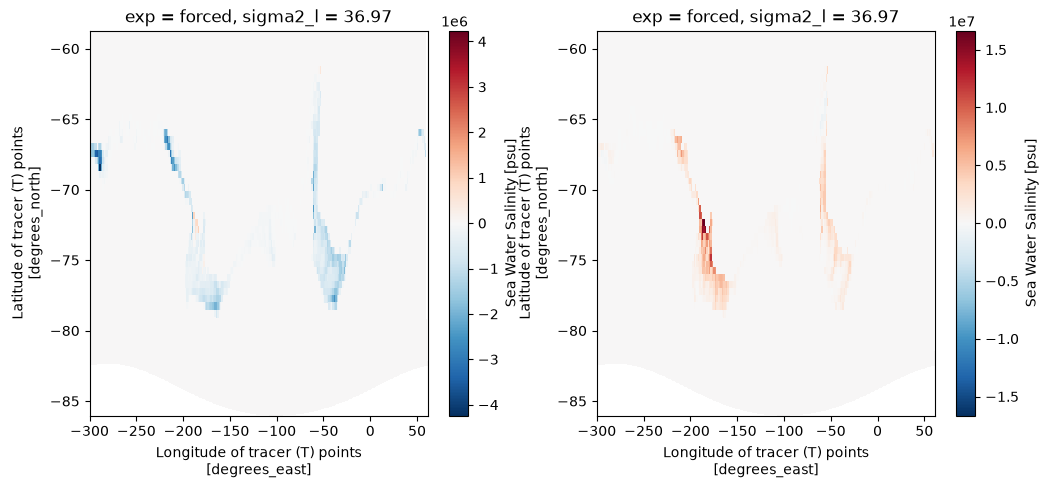

In [37]:
sigma = 36.974

fig, ax = plt.subplots(1, 2, figsize = (12, 5))
wmts_ds.surface_exchange_flux_salt.isel(exp = 0).mean("year").sel(
                                                                  sigma2_l = sigma, method = "nearest").plot(x = "geolon", y = "geolat", ax = ax[0])
wmts_ds.surface_exchange_flux_heat.isel(exp = 0).mean("year").sel(
                                                                  sigma2_l = sigma, method = "nearest").plot(x = "geolon", y = "geolat", ax = ax[1])

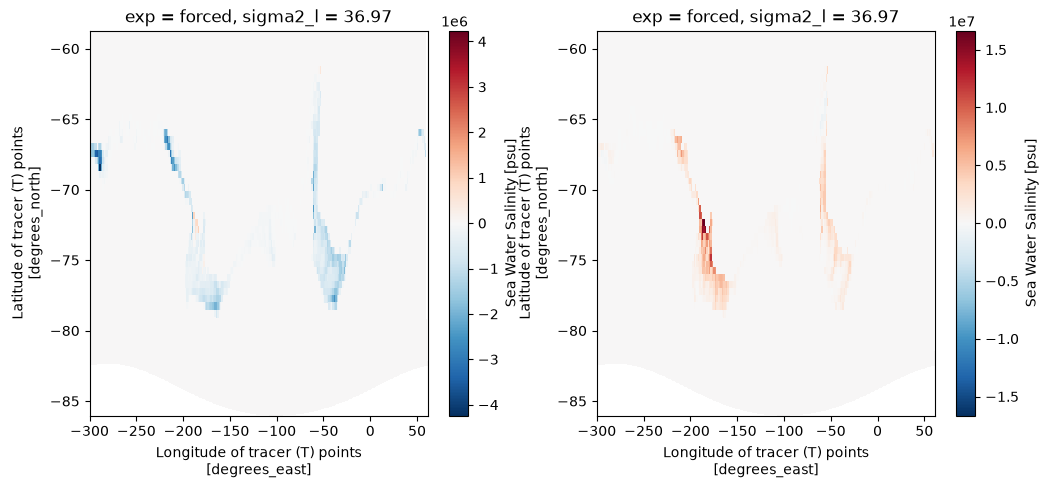

In [38]:
sigma = 36.974

fig, ax = plt.subplots(1, 2, figsize = (12, 5))
wmts_ds.surface_exchange_flux_salt.isel(exp = 0).mean("year").sel(
                                                                  sigma2_l = sigma, method = "nearest").plot(x = "geolon", y = "geolat", ax = ax[0])
wmts_ds.surface_exchange_flux_heat.isel(exp = 0).mean("year").sel(
                                                                  sigma2_l = sigma, method = "nearest").plot(x = "geolon", y = "geolat", ax = ax[1])

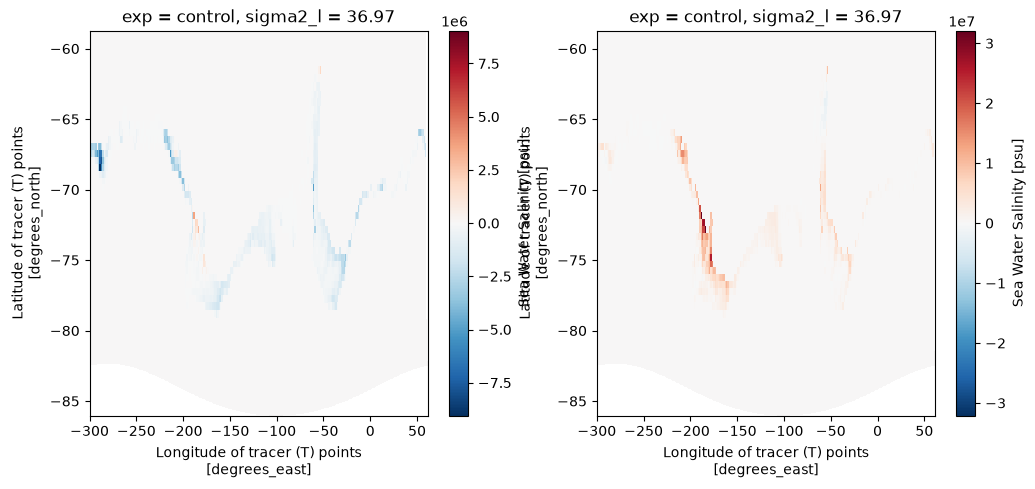

In [39]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5))
wmts_ds.isel(exp = 1).mean("year").surface_exchange_flux_salt.sel(sigma2_l = sigma, method = "nearest").plot(x = "geolon", y = "geolat", ax = ax[0])
wmts_ds.isel(exp = 1).mean("year").surface_exchange_flux_heat.sel(sigma2_l = sigma, method = "nearest").plot(x = "geolon", y = "geolat", ax = ax[1])